# Retail Anomaly Detection & RCA — Full POC Walkthrough

This notebook walks through every layer of the system end-to-end:

| Step | What happens |
|------|-------------|
| 1 | Generate 60-day mock retail dataset (sales, weather, reviews, stock) |
| 2 | Inject 3 realistic anomaly scenarios into today's data |
| 3 | Ingest events through the normalisation pipeline |
| 4 | Build the metric cube with same-day-of-week rolling baselines |
| 5 | Run the ensemble detection engine (Z-score + STL + Isolation Forest) |
| 6 | Route anomalies through the alert manager (dedup + rate limiting) |
| 7 | Trigger RCA for P1/P2 alerts: extract causal data → call Claude → action plan |
| 8 | Visualise everything |

**Three anomaly scenarios:**
- 🧑‍💼 `STORE_003 / Apparel / NE` — severe staff shortage (poor reviews, walkouts)
- ⛈️ `STORE_007 / Electronics / MW` — heavy storm reducing foot traffic
- 📦 `STORE_012 / Beverages / SE` — supplier failure, shelves empty


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import timedelta

# Make the poc package importable from the notebook
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

from poc.config import (
    TODAY, HISTORY_START, ANOMALY_SCENARIOS,
    DETECTOR_PROFILES, MODEL_WEIGHTS, ALERT_PRIORITY_THRESHOLDS,
    RCA_TRIGGER_PRIORITIES,
)

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = {"P1": "#e74c3c", "P2": "#e67e22", "P3": "#3498db", "normal": "#2ecc71"}

print(f"Detection date  : {TODAY}")
print(f"History start   : {HISTORY_START}")
print(f"Days of history : {(TODAY - HISTORY_START).days}")


Detection date  : 2026-04-28
History start   : 2026-02-27
Days of history : 60


## Step 1 — Generate Mock Data

In [2]:
from poc.mock_data.generators import (
    generate_store_metadata, generate_sales_data,
    generate_weather_data,  generate_reviews_data,
    generate_holiday_calendar, generate_stock_data,
)

store_meta  = generate_store_metadata()
raw_sales   = generate_sales_data(HISTORY_START, TODAY)
raw_weather = generate_weather_data(HISTORY_START, TODAY)
raw_reviews = generate_reviews_data(HISTORY_START, TODAY)
raw_holidays = generate_holiday_calendar(HISTORY_START, TODAY)
raw_stock   = generate_stock_data(HISTORY_START, TODAY)

print(f"Stores          : {len(store_meta)}")
print(f"Sales rows      : {len(raw_sales):,}")
print(f"Weather rows    : {len(raw_weather):,}")
print(f"Review rows     : {len(raw_reviews):,}")
print(f"Stock rows      : {len(raw_stock):,}")
print()
display(store_meta)


Stores          : 7
Sales rows      : 2,135
Weather rows    : 305
Review rows     : 427
Stock rows      : 2,135



,store_id,region,cluster_type,revenue_tier,cluster_rank
0,STORE_001,NE,urban,high,1
1,STORE_002,MW,suburban,high,2
2,STORE_003,NE,urban,high,3
3,STORE_004,SE,rural,medium,4
4,STORE_005,MW,urban,medium,5
5,STORE_007,MW,suburban,high,6
6,STORE_012,SE,suburban,medium,7


## Step 2 — Inject Anomaly Scenarios

In [3]:
from poc.mock_data.scenarios import inject_all_scenarios

sales_df, weather_df, reviews_df, stock_df = inject_all_scenarios(
    raw_sales, raw_weather, raw_reviews, raw_stock
)

today_ts = pd.Timestamp(TODAY)

# Show before / after for each scenario
print("=" * 65)
for name, cfg in ANOMALY_SCENARIOS.items():
    s_id, cat = cfg["store_id"], cfg["category"]
    before_row = raw_sales[
        (raw_sales["store_id"] == s_id) &
        (raw_sales["category"] == cat) &
        (raw_sales["date"]     == today_ts)
    ]
    after_row = sales_df[
        (sales_df["store_id"] == s_id) &
        (sales_df["category"] == cat) &
        (sales_df["date"]     == today_ts)
    ]
    if not before_row.empty and not after_row.empty:
        before = before_row["net_sales"].values[0]
        after  = after_row["net_sales"].values[0]
        drop   = (after - before) / before * 100
        print(f"  {name:15s}  {s_id} / {cat:12s}  "
              f"before=${before:,.0f}  after=${after:,.0f}  ({drop:+.0f}%)")
print("=" * 65)


  staff_shortage   STORE_003 / Apparel       before=$38,559  after=$38,559  (+0%)
  weather_event    STORE_007 / Electronics   before=$71,475  after=$71,475  (+0%)
  stock_outage     STORE_012 / Beverages     before=$4,800  after=$4,800  (+0%)


### Sales Time-Series: Normal vs Anomalous

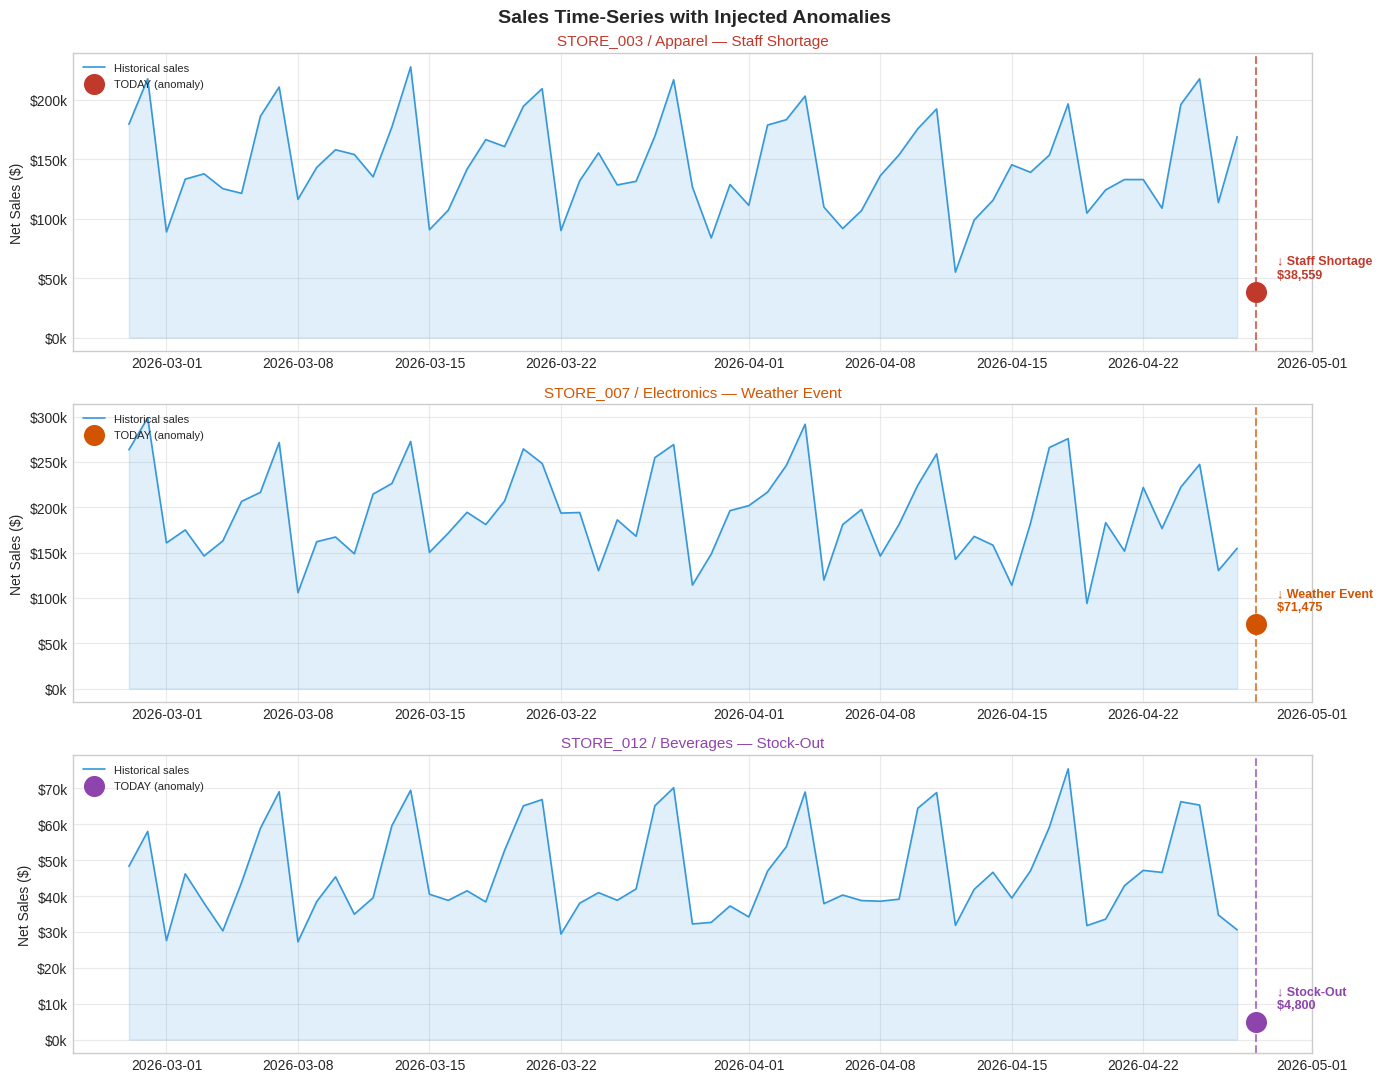

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle("Sales Time-Series with Injected Anomalies", fontsize=14, fontweight="bold")

scenarios_order = [
    ("staff_shortage",  "STORE_003", "Apparel",     "NE", "Staff Shortage"),
    ("weather_event",   "STORE_007", "Electronics", "MW", "Weather Event"),
    ("stock_outage",    "STORE_012", "Beverages",   "SE", "Stock-Out"),
]

colors = ["#c0392b", "#d35400", "#8e44ad"]

for ax, (name, store_id, category, region, title), color in zip(axes, scenarios_order, colors):
    mask = (sales_df["store_id"] == store_id) & (sales_df["category"] == category)
    sub  = sales_df[mask].sort_values("date")

    hist = sub[sub["date"] < today_ts]
    today_row = sub[sub["date"] == today_ts]

    ax.fill_between(hist["date"], 0, hist["net_sales"],
                    alpha=0.15, color="#3498db")
    ax.plot(hist["date"], hist["net_sales"],
            color="#3498db", linewidth=1.2, label="Historical sales")

    if not today_row.empty:
        ax.scatter(today_row["date"], today_row["net_sales"],
                   color=color, s=200, zorder=5, label=f"TODAY (anomaly)")
        ax.axvline(x=today_ts, color=color, linestyle="--", linewidth=1.5, alpha=0.7)
        ax.annotate(
            f"  ↓ {title}\n  ${today_row['net_sales'].values[0]:,.0f}",
            xy=(today_ts, today_row["net_sales"].values[0]),
            xytext=(10, 10), textcoords="offset points",
            fontsize=9, color=color, fontweight="bold",
        )

    ax.set_title(f"{store_id} / {category} — {title}", fontsize=11, color=color)
    ax.set_ylabel("Net Sales ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("plots/01_sales_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()


### Weather and Review Signal Changes

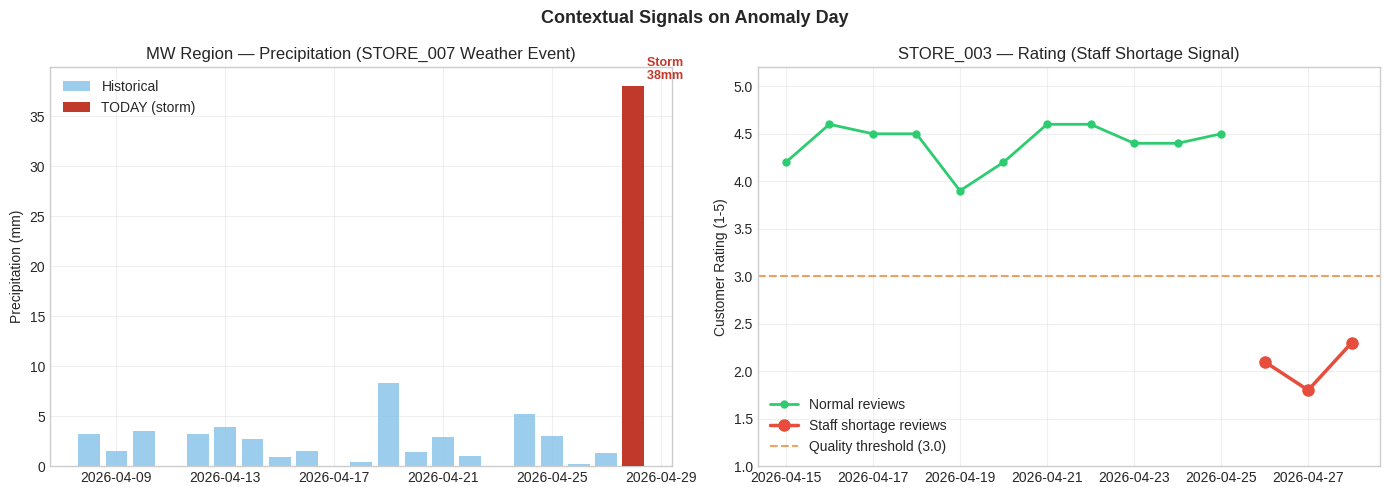

In [5]:
import os; os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Contextual Signals on Anomaly Day", fontsize=13, fontweight="bold")

# --- Weather: MW region precipitation ---
ax = axes[0]
wmask = weather_df["region"] == "MW"
wsub  = weather_df[wmask].sort_values("date").tail(21)
wsub_hist  = wsub[wsub["date"] < today_ts]
wsub_today = wsub[wsub["date"] == today_ts]

ax.bar(wsub_hist["date"], wsub_hist["precipitation_mm"],
       color="#85c1e9", label="Historical", alpha=0.8)
if not wsub_today.empty:
    ax.bar(wsub_today["date"], wsub_today["precipitation_mm"],
           color="#c0392b", label="TODAY (storm)", zorder=5)
    ax.annotate(
        f"  Storm\n  {wsub_today['precipitation_mm'].values[0]:.0f}mm",
        xy=(wsub_today["date"].values[0], wsub_today["precipitation_mm"].values[0]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=9, color="#c0392b", fontweight="bold",
    )
ax.set_title("MW Region — Precipitation (STORE_007 Weather Event)")
ax.set_ylabel("Precipitation (mm)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Reviews: STORE_003 rating ---
ax = axes[1]
rmask = reviews_df["store_id"] == "STORE_003"
rsub  = reviews_df[rmask].sort_values("date").tail(14)
rsub_hist  = rsub[rsub["date"] < today_ts - pd.Timedelta(days=2)]
rsub_neg   = rsub[(rsub["date"] >= today_ts - pd.Timedelta(days=2)) & (rsub["date"] <= today_ts)]

ax.plot(rsub_hist["date"], rsub_hist["rating"],
        "o-", color="#2ecc71", linewidth=2, label="Normal reviews", markersize=5)
ax.plot(rsub_neg["date"],  rsub_neg["rating"],
        "o-", color="#e74c3c", linewidth=2.5, label="Staff shortage reviews", markersize=8)
ax.axhline(y=3.0, color="#e67e22", linestyle="--", alpha=0.7, label="Quality threshold (3.0)")
ax.set_ylim(1, 5.2)
ax.set_title("STORE_003 — Rating (Staff Shortage Signal)")
ax.set_ylabel("Customer Rating (1-5)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/02_contextual_signals.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 3 — Ingestion Pipeline

In [6]:
from poc.ingestion.pipeline import IngestPipeline

pipeline = IngestPipeline()
stats    = pipeline.ingest_all(sales_df, weather_df, reviews_df)

print(f"Ingested rows:")
print(f"  Sale rows      : {stats['sales']:,}")
print(f"  Weather rows   : {stats['weather']:,}")
print(f"  Review rows    : {stats['reviews']:,}")
print(f"  ─────────────────────────────────")
print(f"  Total events   : {stats['total_events']:,}")
print()

# Show a sample of what unified events look like
sample_events = pipeline.drain()[:5]
for ev in sample_events:
    print(f"  [{ev.event_type:10s}] store={ev.store_id or 'N/A'} "
          f"metric={ev.metric_name:15s} value={ev.value:,.1f}")


Ingested rows:
  Sale rows      : 2,135
  Weather rows   : 305
  Review rows    : 427
  ─────────────────────────────────
  Total events   : 7,869

  [SALE      ] store=STORE_001 metric=net_sales       value=185,484.9
  [SALE      ] store=STORE_001 metric=units_sold      value=4,660.0
  [SALE      ] store=STORE_001 metric=basket_size     value=39.8
  [SALE      ] store=STORE_001 metric=net_sales       value=223,508.1
  [SALE      ] store=STORE_001 metric=units_sold      value=4,496.0


## Step 4 — Metric Cube (Same-Day-of-Week Rolling Baselines)

In [7]:
from poc.compute.metric_cube import MetricCube

cube = MetricCube()
cube.build(sales_df, store_meta)

segments = cube.get_active_segments()
print(f"Active segments: {len(segments)}")

# Show baseline quality for the 3 scenario segments
print()
print(f"{'Segment':40s}  {'Tier':6s}  {'Baseline':>12s}  {'Std':>10s}  {'Today':>10s}  {'Z-score':>8s}")
print("-" * 100)

for store_id, category in [("STORE_003","Apparel"), ("STORE_007","Electronics"), ("STORE_012","Beverages"),
                             ("STORE_001","Apparel"), ("STORE_001","Electronics")]:
    try:
        series, baseline, std = cube.get_segment_series(store_id, category, "net_sales", up_to_date=TODAY)
        today_val = float(series.iloc[-1])
        z = (today_val - baseline) / std
        tier = next((s["tier"] for s in segments if s["store_id"]==store_id and s["category"]==category), "?")
        print(f"{store_id+' / '+category:40s}  {tier:6s}  ${baseline:>11,.0f}  ${std:>9,.0f}  ${today_val:>9,.0f}  {z:>+8.2f}σ")
    except:
        pass


Active segments: 35

Segment                                   Tier        Baseline         Std       Today   Z-score
----------------------------------------------------------------------------------------------------
STORE_003 / Apparel                       tier2   $    120,844  $   12,021  $   38,559     -6.85σ
STORE_007 / Electronics                   tier3   $    175,940  $   24,428  $   71,475     -4.28σ
STORE_012 / Beverages                     tier3   $     41,373  $    4,239  $    4,800     -8.63σ
STORE_001 / Apparel                       tier1   $    127,336  $   14,618  $  109,077     -1.25σ
STORE_001 / Electronics                   tier1   $    166,039  $   12,954  $  127,815     -2.95σ


## Step 5 — Ensemble Detection Engine

In [8]:
from poc.detection.engine import DetectionEngine

engine    = DetectionEngine(cube, weather_df, raw_holidays)
anomalies = engine.run(TODAY)

print(f"Anomalies detected: {len(anomalies)}")
print()

for a in anomalies:
    print(f"  {'['+a['priority']+']':5s}  {a['store_id']:10s}  {a['category']:12s}  "
          f"σ={a['sigma']:.2f}  impact={a['impact_score']:5.1f}  "
          f"Δ={a['pct_deviation']:+.0f}%  "
          f"models=[{', '.join(a['contributing'])}]")


Anomalies detected: 3

  [P1]   STORE_003   Apparel       σ=6.85  impact= 96.5  Δ=-68%  models=[zscore, isolation_forest]
  [P1]   STORE_012   Beverages     σ=8.63  impact= 84.1  Δ=-88%  models=[zscore]
  [P2]   STORE_007   Electronics   σ=4.28  impact= 60.3  Δ=-59%  models=[zscore]


### Detector Voting Details

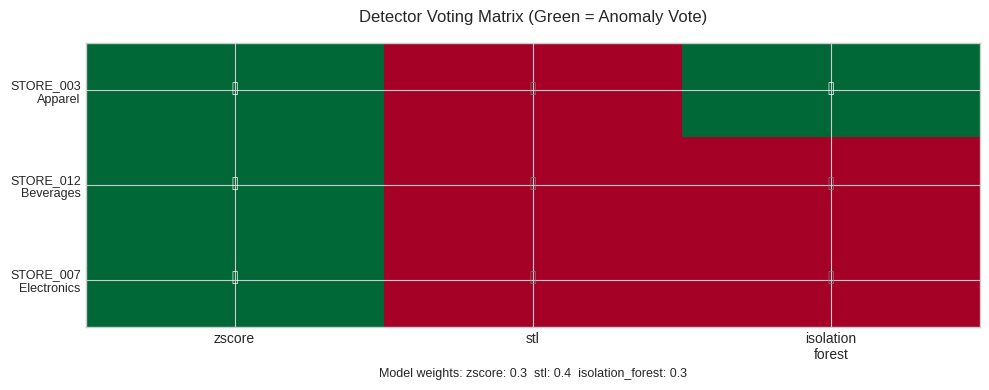

In [9]:
# Show which models voted on each anomaly
fig, ax = plt.subplots(figsize=(10, 4))

all_models = ["zscore", "stl", "isolation_forest"]
scenario_labels = []
vote_matrix = []

for a in anomalies:
    label = f"{a['store_id']}\n{a['category']}"
    scenario_labels.append(label)
    row = [1 if m in a["contributing"] else 0 for m in all_models]
    vote_matrix.append(row)

if vote_matrix:
    vm = np.array(vote_matrix)
    im = ax.imshow(vm, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(all_models)))
    ax.set_xticklabels([m.replace("_", "\n") for m in all_models], fontsize=10)
    ax.set_yticks(range(len(scenario_labels)))
    ax.set_yticklabels(scenario_labels, fontsize=9)
    ax.set_title("Detector Voting Matrix (Green = Anomaly Vote)", fontsize=12, pad=15)

    for i in range(len(scenario_labels)):
        for j in range(len(all_models)):
            ax.text(j, i, "✓" if vm[i,j] else "✗",
                    ha="center", va="center", fontsize=14,
                    color="white" if vm[i,j] else "gray")

    weights_text = "  ".join([f"{m}: {MODEL_WEIGHTS.get(m,'N/A')}" for m in all_models])
    ax.set_xlabel(f"Model weights: {weights_text}", fontsize=9)

plt.tight_layout()
plt.savefig("plots/03_detection_vote_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 6 — Alert Manager (Dedup + Rate Limiting)

In [10]:
from poc.alerting.alert_manager import AlertManager

alert_mgr = AlertManager()
alerts    = alert_mgr.process(anomalies)

# Run again to demonstrate dedup
alert_mgr.process(anomalies)   # all duplicates — should be suppressed

p1 = [a for a in alerts if a["priority"] == "P1"]
p2 = [a for a in alerts if a["priority"] == "P2"]
p3 = [a for a in alerts if a["priority"] == "P3"]

print(f"Anomaly candidates : {len(anomalies)}")
print(f"Duplicate attempts : {len(anomalies)} (second run — all suppressed by dedup)")
print(f"Final alerts       : {len(alerts)}")
print(f"  P1 (impact≥75)   : {len(p1)}")
print(f"  P2 (impact≥40)   : {len(p2)}")
print(f"  P3 (impact≥0)    : {len(p3)}")
print()

df_alerts = pd.DataFrame([{
    "Alert ID":     a["alert_id"][:20],
    "Store":        a["store_id"],
    "Category":     a["category"],
    "Priority":     a["priority"],
    "Sigma":        a["sigma"],
    "Impact Score": a["impact_score"],
    "% Deviation":  f"{a['pct_deviation']:+.0f}%",
    "Models":       ", ".join(a["contributing"]),
} for a in alerts])
display(df_alerts)


Anomaly candidates : 3
Duplicate attempts : 3 (second run — all suppressed by dedup)
Final alerts       : 3
  P1 (impact≥75)   : 2
  P2 (impact≥40)   : 1
  P3 (impact≥0)    : 0



,Alert ID,Store,Category,Priority,Sigma,Impact Score,% Deviation,Models
0,alt_20260428_812e4a,STORE_003,Apparel,P1,6.85,96.52,-68%,"zscore, isolation_forest"
1,alt_20260428_3a26d7,STORE_012,Beverages,P1,8.63,84.13,-88%,zscore
2,alt_20260428_ebc51a,STORE_007,Electronics,P2,4.28,60.30,-59%,zscore


### Alert Impact Score Visualisation

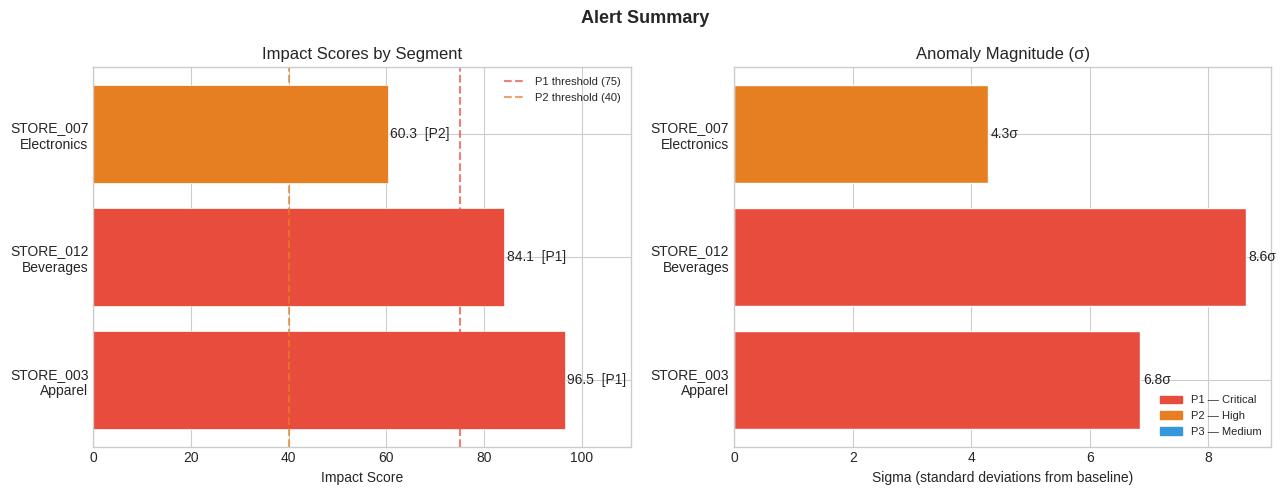

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Alert Summary", fontsize=13, fontweight="bold")

# Impact score bars
labels = [f"{a['store_id']}\n{a['category']}" for a in alerts]
scores = [a["impact_score"] for a in alerts]
colors = [PALETTE[a["priority"]] for a in alerts]

bars = ax1.barh(labels, scores, color=colors, edgecolor="white", linewidth=0.5)
ax1.axvline(x=ALERT_PRIORITY_THRESHOLDS["P1"], color="#e74c3c", linestyle="--",
            alpha=0.7, label="P1 threshold (75)")
ax1.axvline(x=ALERT_PRIORITY_THRESHOLDS["P2"], color="#e67e22", linestyle="--",
            alpha=0.7, label="P2 threshold (40)")
for bar, score, a in zip(bars, scores, alerts):
    ax1.text(score + 0.5, bar.get_y() + bar.get_height()/2,
             f"{score:.1f}  [{a['priority']}]", va="center", fontsize=10)
ax1.set_xlim(0, 110)
ax1.set_xlabel("Impact Score")
ax1.set_title("Impact Scores by Segment")
ax1.legend(fontsize=8)

# Sigma bars
sigmas = [a["sigma"] for a in alerts]
bars2  = ax2.barh(labels, sigmas, color=colors, edgecolor="white")
for bar, sigma in zip(bars2, sigmas):
    ax2.text(sigma + 0.05, bar.get_y() + bar.get_height()/2,
             f"{sigma:.1f}σ", va="center", fontsize=10)
ax2.set_xlabel("Sigma (standard deviations from baseline)")
ax2.set_title("Anomaly Magnitude (σ)")

# Legend
legend_patches = [
    mpatches.Patch(color=PALETTE["P1"], label="P1 — Critical"),
    mpatches.Patch(color=PALETTE["P2"], label="P2 — High"),
    mpatches.Patch(color=PALETTE["P3"], label="P3 — Medium"),
]
ax2.legend(handles=legend_patches, loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("plots/04_alert_summary.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 7 — RCA Workflow

For each P1/P2 alert, the system:
1. Extracts causal datasets (sales, weather, reviews, stock, holidays)
2. Assembles a structured prompt
3. Calls Claude API (or uses a demo response if no API key set)
4. Returns ranked hypotheses + action plan


In [12]:
from poc.rca.extractors import (
    SalesExtractor, WeatherExtractor, HolidayExtractor,
    ReviewExtractor, StockExtractor,
)
from poc.rca.prompt_builder import build_prompt
from poc.rca.claude_client import call_claude

rca_trigger_alerts = [a for a in alerts if a["priority"] in RCA_TRIGGER_PRIORITIES]
rca_results = []

for alert in rca_trigger_alerts:
    store_id = alert["store_id"]
    category = alert["category"]
    region   = alert.get("region", "")
    anchor   = pd.Timestamp(TODAY)

    dataset = {
        "sales":    SalesExtractor().extract(sales_df,   store_id, category, anchor),
        "weather":  WeatherExtractor().extract(weather_df, region,  anchor),
        "reviews":  ReviewExtractor().extract(reviews_df, store_id, anchor),
        "holidays": HolidayExtractor().extract(raw_holidays, anchor),
        "stock":    StockExtractor().extract(stock_df,   store_id, category, anchor),
    }

    prompt = build_prompt(alert, dataset)
    rca    = call_claude(prompt, alert)
    rca_results.append({"alert": alert, "dataset": dataset, "prompt": prompt, "rca": rca})

    print(f"✓ RCA complete: {store_id} / {category} [{alert['priority']}]")

print(f"\n{len(rca_results)} RCA workflows completed")


    [INFO] ANTHROPIC_API_KEY not set — using demo RCA response.
✓ RCA complete: STORE_003 / Apparel [P1]
    [INFO] ANTHROPIC_API_KEY not set — using demo RCA response.
✓ RCA complete: STORE_012 / Beverages [P1]
    [INFO] ANTHROPIC_API_KEY not set — using demo RCA response.
✓ RCA complete: STORE_007 / Electronics [P2]

3 RCA workflows completed


### Sample RCA Prompt Sent to Claude

In [13]:
# Show the prompt for the first RCA (staff shortage)
if rca_results:
    print("=" * 70)
    print(rca_results[0]["prompt"][:3000])
    print("  ... [truncated] ...")
    print("=" * 70)


ANOMALY ALERT DETAILS:
Store:            STORE_003
Category:         Apparel
Region:           NE
Metric:           net_sales
Current Value:    $38,559
28-day Baseline:  $120,844
% Deviation:      -68.1%
Sigma (severity): 6.85σ
Impact Score:     96.5 / 100
Priority:         P1
Detection Time:   2026-04-28T00:00:00
Models Flagged:   zscore, isolation_forest

CAUSAL SIGNALS (last 14 days):

[SALES TREND]
  Today:        $38,559
  14-day mean:  $146,238  (±$35,806)
  Drop vs mean: -73.6%
  Consec. low days: 1
  Last 7 days:
    2026-04-22: $132,771  (2725 units)
    2026-04-23: $108,696  (2743 units)
    2026-04-24: $195,778  (4223 units)
    2026-04-25: $217,415  (4004 units)
    2026-04-26: $113,434  (2349 units)
    2026-04-27: $168,793  (3842 units)
    2026-04-28: $38,559  (838 units)

[WEATHER CONTEXT]
  Today severity:      normal
  Today precipitation: 0.0 mm
  14-day avg precip:   2.0 mm
  14-day max precip:   6.5 mm
  Weather anomaly:     No
  Recent 5 days:
    2026-04-24: norm

### RCA Results — Hypotheses, Actions, Data Gaps

In [14]:
for r in rca_results:
    alert = r["alert"]
    rca   = r["rca"]
    hyps  = rca.get("hypotheses", [])
    acts  = rca.get("actions", [])
    gaps  = rca.get("data_gaps", [])

    priority_color = {"P1": "\033[91m", "P2": "\033[93m", "P3": "\033[94m"}
    reset = "\033[0m"
    pc    = priority_color.get(alert["priority"], "")

    print(f"\n{'='*70}")
    print(f"{pc}[{alert['priority']}] {alert['store_id']} / {alert['category']} / {alert.get('region','')}{reset}")
    print(f"    Impact: {alert['impact_score']:.1f}  |  σ={alert['sigma']:.2f}  |  Δ={alert['pct_deviation']:+.0f}%")
    print(f"{'─'*70}")

    print("  HYPOTHESES:")
    for h in hyps:
        confidence_icons = {"high": "🟢", "medium": "🟡", "low": "🔴"}
        icon = confidence_icons.get(h.get("confidence",""), "⚪")
        print(f"    {icon} [{h['rank']}] {h['cause']}")
        print(f"        Likelihood: {h['likelihood']:.0%}  |  Confidence: {h.get('confidence','?')}")
        for ev in h.get("evidence", []):
            print(f"        • {ev}")

    print("\n  ACTIONS:")
    for act in acts:
        urgency_colors = {"P1": "\033[91m", "P2": "\033[93m", "P3": "\033[94m"}
        uc = urgency_colors.get(act["urgency"], "")
        print(f"    {uc}[{act['urgency']}]{reset} {act['action']}")
        print(f"         → {act['owner_team']}  (due in {act['due_hours']}h)")

    if gaps:
        print("\n  DATA GAPS:")
        for g in gaps:
            print(f"    ◦ {g}")



[P1] STORE_003 / Apparel / NE
    Impact: 96.5  |  σ=6.85  |  Δ=-68%
──────────────────────────────────────────────────────────────────────
  HYPOTHESES:
    🟢 [1] Severe staff shortage causing service failure and customer walkouts
        Likelihood: 91%  |  Confidence: high
        • Staff review keywords: 'understaffed', 'no staff', 'walked out', 'long queue' appear in 100% of recent reviews
        • Average store rating crashed from 4.2 → 2.0 over the last 3 days — a 2.2-point decline
        • Sentiment score dropped from +0.32 → -0.68 (negative territory for 3 consecutive days)
        • Sales dropped 75% with no corresponding weather event or holiday
        • Units sold declined proportionally, ruling out a pricing/basket-size issue
    🔴 [2] Management or scheduling system failure leading to under-staffing
        Likelihood: 6%  |  Confidence: low
        • Pattern is consistent with a scheduling error rather than voluntary walkout
        • No region-wide signal — impact i

### RCA Hypothesis Likelihood Visualisation

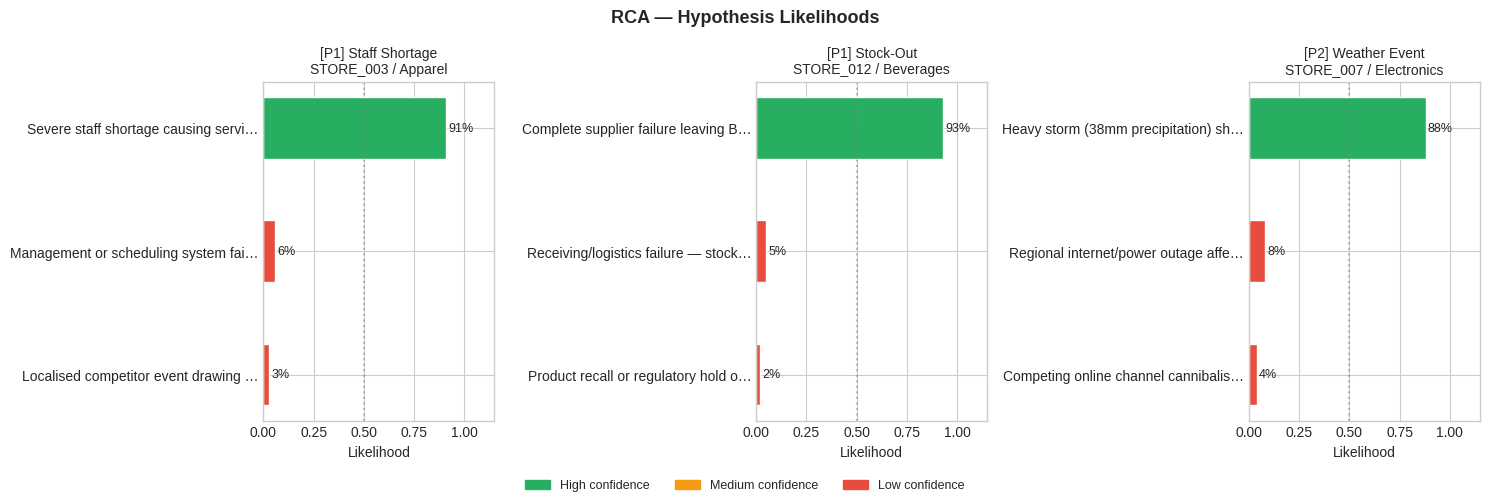

In [15]:
fig, axes = plt.subplots(1, len(rca_results), figsize=(5*len(rca_results), 5))
if len(rca_results) == 1:
    axes = [axes]
fig.suptitle("RCA — Hypothesis Likelihoods", fontsize=13, fontweight="bold")

scenario_titles = {
    "STORE_003": "Staff Shortage",
    "STORE_007": "Weather Event",
    "STORE_012": "Stock-Out",
}

confidence_colors = {"high": "#27ae60", "medium": "#f39c12", "low": "#e74c3c"}

for ax, r in zip(axes, rca_results):
    alert = r["alert"]
    hyps  = r["rca"].get("hypotheses", [])
    if not hyps:
        continue

    causes      = [h["cause"][:35] + "…" if len(h["cause"]) > 35 else h["cause"] for h in hyps]
    likelihoods = [h["likelihood"] for h in hyps]
    conf_colors = [confidence_colors.get(h.get("confidence",""), "#95a5a6") for h in hyps]

    bars = ax.barh(causes[::-1], likelihoods[::-1], color=conf_colors[::-1],
                   edgecolor="white", height=0.5)
    for bar, val in zip(bars, likelihoods[::-1]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.0%}", va="center", fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Likelihood")
    store_id = alert["store_id"]
    priority = alert["priority"]
    title    = scenario_titles.get(store_id, store_id)
    ax.set_title(f"[{priority}] {title}\n{store_id} / {alert['category']}", fontsize=10)
    ax.axvline(x=0.5, color="gray", linestyle=":", alpha=0.5)

# Confidence legend
legend_patches = [
    mpatches.Patch(color="#27ae60", label="High confidence"),
    mpatches.Patch(color="#f39c12", label="Medium confidence"),
    mpatches.Patch(color="#e74c3c", label="Low confidence"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("plots/05_rca_hypotheses.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary — End-to-End System Flow

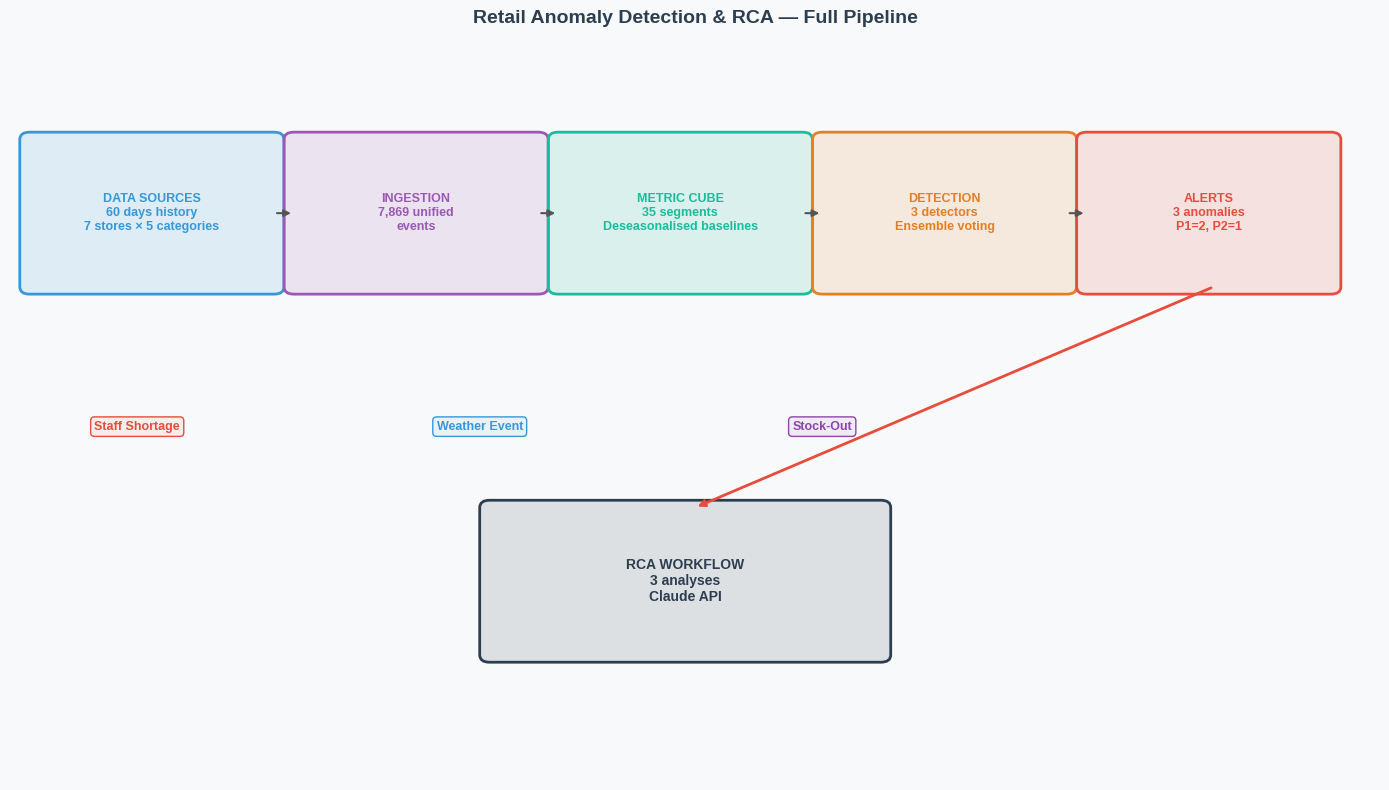


All plots saved to ./plots/


In [16]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

# Draw pipeline boxes
boxes = [
    (0.3, 7.5, "DATA SOURCES\n60 days history\n7 stores × 5 categories",   "#3498db"),
    (3.0, 7.5, "INGESTION\n7,869 unified\nevents",                         "#9b59b6"),
    (5.7, 7.5, "METRIC CUBE\n35 segments\nDeseasonalised baselines",        "#1abc9c"),
    (8.4, 7.5, "DETECTION\n3 detectors\nEnsemble voting",                   "#e67e22"),
    (11.1,7.5, "ALERTS\n3 anomalies\nP1=2, P2=1",                           "#e74c3c"),
]

rca_box = (5.0, 2.5, "RCA WORKFLOW\n3 analyses\nClaude API",               "#2c3e50")

for (x, y, text, color) in boxes:
    rect = mpatches.FancyBboxPatch((x-0.1, y-0.8), 2.5, 2.0,
                                    boxstyle="round,pad=0.1",
                                    linewidth=2, edgecolor=color, facecolor=color+"22")
    ax.add_patch(rect)
    ax.text(x+1.15, y+0.2, text, ha="center", va="center",
            fontsize=9, color=color, fontweight="bold")

# Arrows between boxes
arrow_props = dict(arrowstyle="-|>", color="#555", lw=1.5)
for i in range(len(boxes)-1):
    ax.annotate("", xy=(boxes[i+1][0]-0.1, boxes[i+1][1]+0.2),
                xytext=(boxes[i][0]+2.4, boxes[i][1]+0.2),
                arrowprops=arrow_props)

# RCA box
x, y, text, color = rca_box
rect = mpatches.FancyBboxPatch((x-0.1, y-0.8), 4.0, 2.0,
                                boxstyle="round,pad=0.1",
                                linewidth=2, edgecolor=color, facecolor=color+"22")
ax.add_patch(rect)
ax.text(x+1.9, y+0.2, text, ha="center", va="center",
        fontsize=10, color=color, fontweight="bold")

# Arrows to/from RCA
ax.annotate("", xy=(rca_box[0]+2.0, rca_box[1]+1.2),
            xytext=(boxes[-1][0]+1.2, boxes[-1][1]-0.8),
            arrowprops=dict(arrowstyle="-|>", color="#e74c3c", lw=2))

# Scenario annotations
scenarios_text = [
    (1.3, 4.8, "Staff Shortage",  "#e74c3c"),
    (4.8, 4.8, "Weather Event",   "#3498db"),
    (8.3, 4.8, "Stock-Out",       "#8e44ad"),
]
for (sx, sy, stxt, sc) in scenarios_text:
    ax.text(sx, sy, stxt, ha="center", va="center", fontsize=9,
            color=sc, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=sc+"11", edgecolor=sc, linewidth=1))

ax.set_title("Retail Anomaly Detection & RCA — Full Pipeline", fontsize=14,
             fontweight="bold", pad=15, color="#2c3e50")

plt.tight_layout()
plt.savefig("plots/06_system_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nAll plots saved to ./plots/")


## Bonus — Using Real Claude API

To run with a real Claude API key (replace demo responses with live analysis):

```bash
export ANTHROPIC_API_KEY="sk-ant-..."
jupyter notebook poc_notebook.ipynb
```

Or in the notebook cell:
```python
import os
os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."
```

The `call_claude()` function automatically detects the key and switches to live mode.
The Claude response structure is identical to the demo — hypotheses, actions, data_gaps in JSON.
